In [12]:
### -------- ЭТАП 1 ---------- ###
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold, cross_val_score
from scipy.stats import skew
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor
import pickle
from sklearn.preprocessing import RobustScaler


sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})
RANDOM_STATE = 42


train = pd.read_csv('../assets/train.csv')
test = pd.read_csv('../assets/test.csv')
sample_submission = pd.read_csv('../assets/sample_submission.csv')

target_raw = train['SalePrice'].copy()
test_ids = test['Id']

print(f"Размер обучающей выборки: {train.shape}")
print(f"Размер тестовой выборки: {test.shape}")
print("\nПервые 5 строк обучающей выборки:")
print(train.head())

Размер обучающей выборки: (1460, 81)
Размер тестовой выборки: (1459, 80)

Первые 5 строк обучающей выборки:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    N

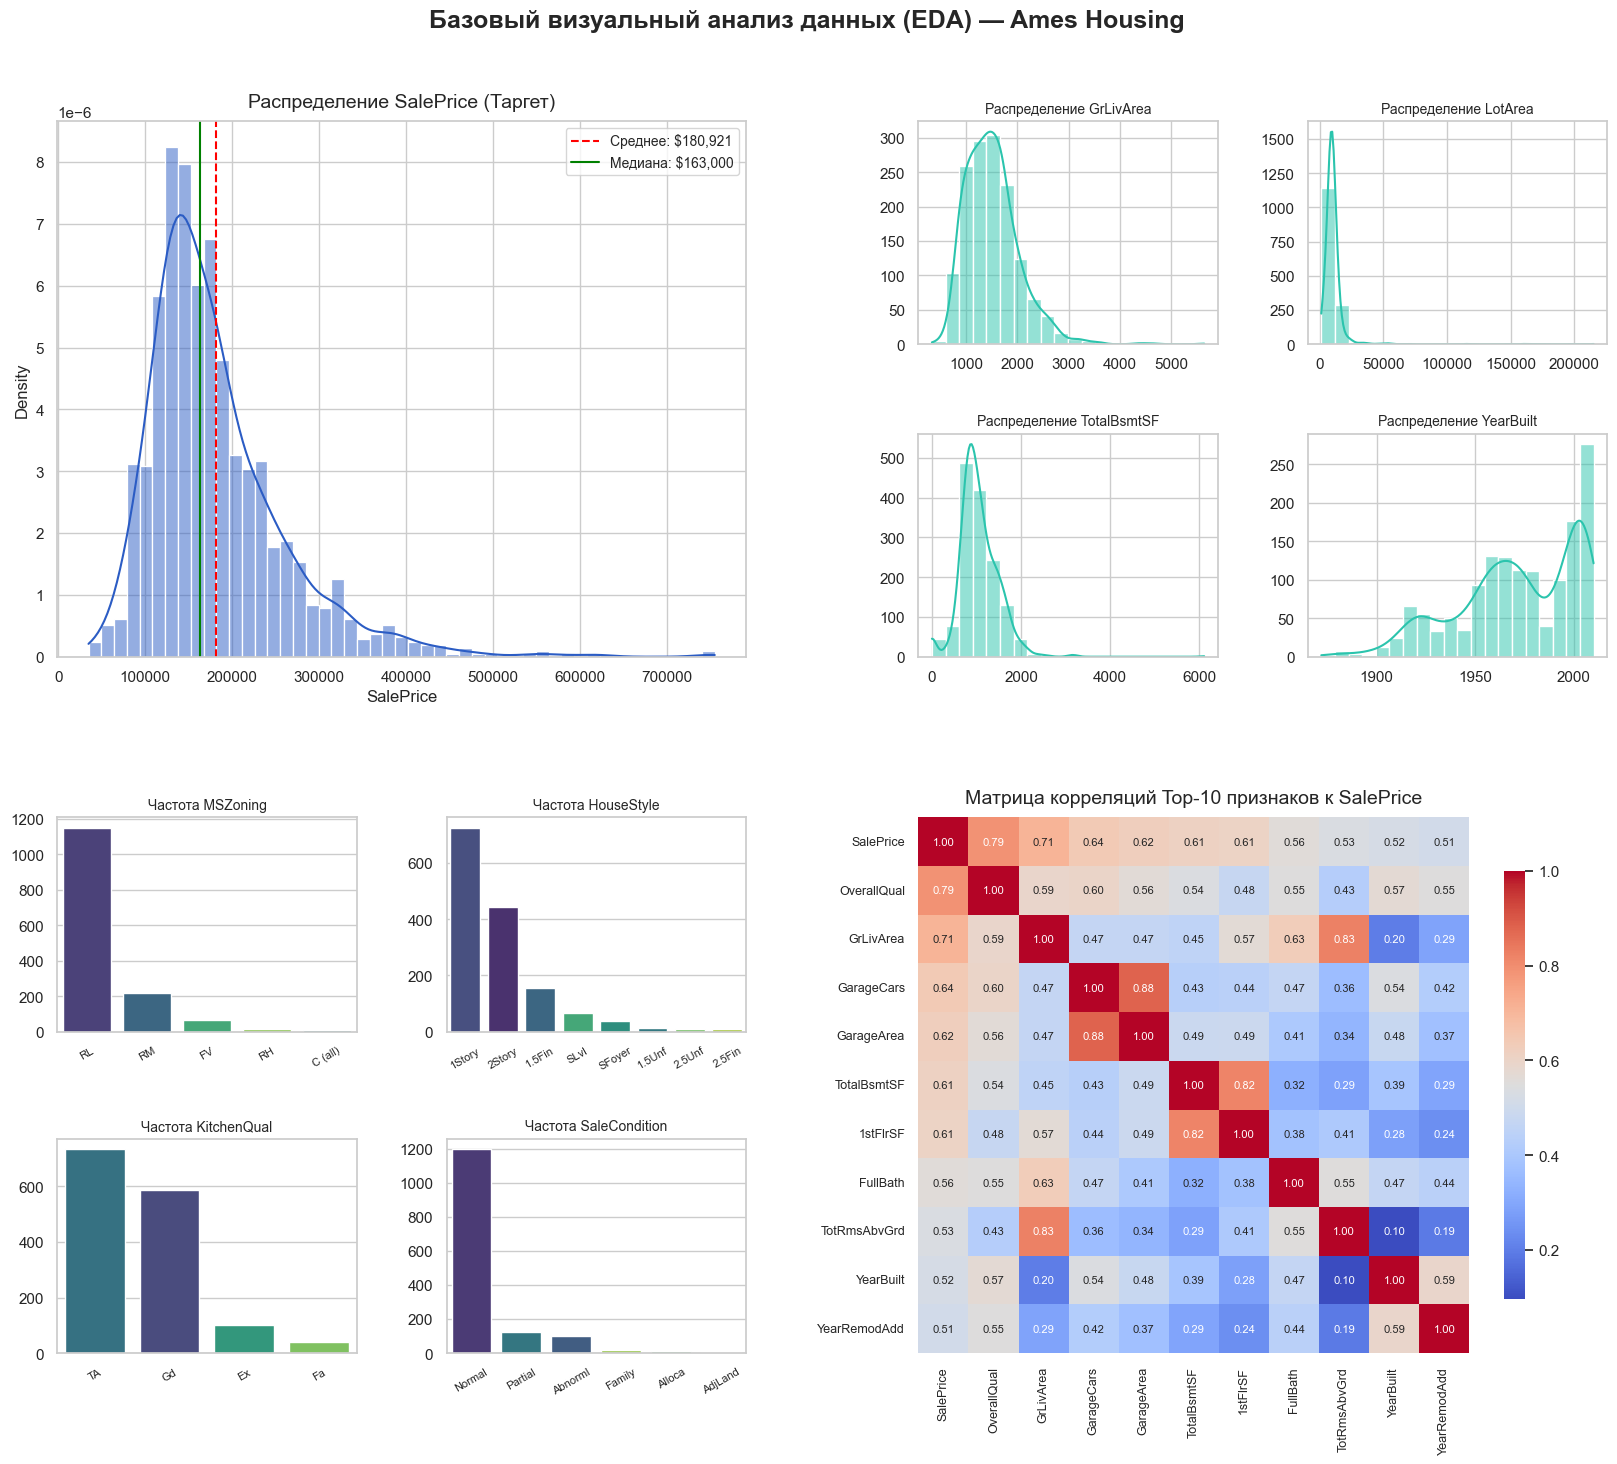

In [ ]:
### EDA ###

# 1. РАСПРЕДЕЛЕНИЕ ЦЕН
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)

ax0 = fig.add_subplot(gs[0, 0])
sns.histplot(target_raw, kde=True, color='#2b5cc4', ax=ax0, stat="density")

# Вычисляем значения для отображения в легенде
mean_val = np.mean(target_raw)
median_val = np.median(target_raw)

# Добавляем линии и выводим округленные цифры в легенду
ax0.axvline(mean_val, color='red', linestyle='--', label=f'Среднее: ${mean_val:,.0f}')
ax0.axvline(median_val, color='green', linestyle='-', label=f'Медиана: ${median_val:,.0f}')

ax0.set_title('Распределение SalePrice (Таргет)', fontsize=14, pad=10)
ax0.legend(fontsize=10) # Теперь легенда покажет и линии, и точные суммы

# 2. САБПЛОТ ЧИСЛОВЫХ ПРИЗНАКОВ

gs_num = gs[0, 1].subgridspec(2, 2, hspace=0.4, wspace=0.3)
num_cols = ['GrLivArea', 'LotArea', 'TotalBsmtSF', 'YearBuilt']

for i, col in enumerate(num_cols):
    row, col_idx = divmod(i, 2)
    ax_n = fig.add_subplot(gs_num[row, col_idx])
    sns.histplot(train[col], kde=True, color='#2bc4ad', ax=ax_n, bins=20)
    ax_n.set_title(f'Распределение {col}', fontsize=10)
    ax_n.set_xlabel('')
    ax_n.set_ylabel('')

# 3. САБПЛОТ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ

gs_cat = gs[1, 0].subgridspec(2, 2, hspace=0.5, wspace=0.3)
cat_cols = ['MSZoning', 'HouseStyle', 'KitchenQual', 'SaleCondition']

for i, col in enumerate(cat_cols):
    row, col_idx = divmod(i, 2)
    ax_c = fig.add_subplot(gs_cat[row, col_idx])
   
    order = train[col].value_counts().index
    sns.countplot(data=train, x=col, order=order, palette='viridis', ax=ax_c, hue=col, legend=False)
    ax_c.set_title(f'Частота {col}', fontsize=10)
    ax_c.set_xlabel('')
    ax_c.set_ylabel('')
    ax_c.tick_params(axis='x', rotation=30, labelsize=8) # Поворот текста, чтобы не налезал

# 4. МАТРИЦА КОРРЕЛЯЦИЙ TOP10 
ax3 = fig.add_subplot(gs[1, 1])
# Находим топ-10 признаков, исключая саму SalePrice из списка строк матрицы
top_corr_features = train.select_dtypes(include=[np.number]).corr()['SalePrice'].abs().sort_values(ascending=False).head(11).index
corr_matrix = train[top_corr_features].corr()

sns.heatmap(
    corr_matrix, 
    annot=True,          
    fmt='.2f',           
    cmap='coolwarm', 
    ax=ax3, 
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8}
)
ax3.set_title('Матрица корреляций Top-10 признаков к SalePrice', fontsize=14, pad=10)
ax3.tick_params(axis='both', labelsize=9)

plt.suptitle('Базовый визуальный анализ данных (EDA) — Ames Housing', fontsize=18, y=0.95, weight='bold')
plt.show()


In [4]:
# ЛОГАРИФМИРОВАНИЕ ТАРГЕТА 
y_train = np.log1p(train['SalePrice'])
train_features = train.drop(['Id', 'SalePrice'], axis=1)
test_features = test.drop(['Id'], axis=1)

In [66]:
# ОБЪЕДИНЕНИЕ ВЫБОРОК
all_data = pd.concat([train_features, test_features], axis=0).reset_index(drop=True)
all_data.drop(['Utilities', 'Street'], axis=1, inplace=True, errors='ignore')

In [67]:
# ПРОСТАЯ ПРЕДОБРАБОТКА (ЗАПОЛНЕНИЕ ПРОПУСКОВ)
n_train = len(train)
num_cols = all_data.select_dtypes(include=[np.number]).columns
for col in num_cols:
    all_data[col] = all_data[col].fillna(all_data.iloc[:n_train][col].median())

cat_cols = all_data.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    all_data[col] = all_data[col].fillna(all_data.iloc[:n_train][col].mode()[0])


In [68]:
# БАЗОВОЕ КОДИРОВАНИЕ
all_data_encoded = pd.get_dummies(all_data, drop_first=True, dtype=int)

In [72]:
# РАЗДЕЛЕНИЕ И BASELINE МОДЕЛЬ
X_train = all_data_encoded.iloc[:n_train].copy()
X_test = all_data_encoded.iloc[n_train:].copy()
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

baseline_xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=RANDOM_STATE)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(baseline_xgb, X_train, y_train, scoring='neg_root_mean_squared_error', cv=kf)
print(f"Baseline CV RMSLE: {np.abs(cv_scores.mean()):.4f}")

baseline_xgb.fit(X_train, y_train)
predictions = np.expm1(baseline_xgb.predict(X_test))


sample_submission['SalePrice'] = predictions
sample_submission.to_csv('baseline_submission.csv', index=False)

Baseline CV RMSLE: 0.1373


In [9]:
### ------------ ЭТАП 2 ------------- ###

# 1. УДАЛЕНИЕ ВЫБРОСОВ И ФИЛЬТРАЦИЯ
train = train.drop(train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index)
train = train.drop(train[train['LotArea'] > 100000].index)

test_ids = test['Id']
y_train = np.log1p(train['SalePrice'])

# Объединение для препроцессинга
all_data = pd.concat([train.drop(['Id', 'SalePrice'], axis=1), test.drop(['Id'], axis=1)], axis=0).reset_index(drop=True)
all_data.drop(['Utilities', 'Street'], axis=1, inplace=True, errors='ignore')

In [10]:
# 2. ПРЕПРОЦЕССИНГ
n_train = len(train)
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType',
             'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond',
             'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']

for col in none_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].astype('object').fillna('None')

# Групповое заполнение пропусков LotFrontage по Neighborhood
train_frontage_medians = all_data.iloc[:n_train].groupby('Neighborhood')['LotFrontage'].median()
global_frontage_median = all_data.iloc[:n_train]['LotFrontage'].median()

all_data['LotFrontage'] = all_data.apply(
    lambda row: train_frontage_medians.get(row['Neighborhood'], global_frontage_median) 
    if pd.isnull(row['LotFrontage']) else row['LotFrontage'], axis=1
)
all_data['GarageYrBlt'] = all_data['GarageYrBlt'].fillna(all_data['YearBuilt'])

# Перевод числовых признаков в строковые категории
all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)
all_data['MoSold'] = all_data['MoSold'].astype(str)
all_data['YrSold'] = all_data['YrSold'].astype(str)

# Заполнение оставшихся числовых и категориальных пропусков строго по Train
for col in all_data.select_dtypes(include=[np.number]).columns:
    all_data[col] = all_data[col].fillna(all_data.iloc[:n_train][col].median())
for col in all_data.select_dtypes(include=['object', 'string']).columns:
    all_data[col] = all_data[col].fillna(all_data.iloc[:n_train][col].mode()[0])      

In [11]:
# 3. FEATURE ENGINEERING & ORDINAL MAP
quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']
for col in qual_cols:
    all_data[col] = all_data[col].map(quality_map)
    
if 'BsmtExposure' in all_data.columns:
    all_data['BsmtExposure'] = all_data['BsmtExposure'].map({'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0})

# Генерация базовых агрегированных фичей
all_data['TotalSF'] = all_data['1stFlrSF'] + all_data['2ndFlrSF'] + all_data['TotalBsmtSF']
all_data['TotalBath'] = all_data['FullBath'] + 0.5 * all_data['HalfBath'] + all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath']
all_data['HouseAge'] = all_data['YrSold'].astype(int) - all_data['YearBuilt']
all_data['YearsSinceRemod'] = all_data['YrSold'].astype(int) - all_data['YearRemodAdd']
all_data['GarageAge'] = all_data['YrSold'].astype(int) - all_data['GarageYrBlt']

# Высокоуровневые синергетические признаки (Взаимодействие признаков)
all_data['Total_Qual'] = all_data['TotalSF'] * all_data['OverallQual']
all_data['High_Quality_SF'] = all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['Total_Porch'] = all_data['OpenPorchSF'] + all_data['EnclosedPorch'] + all_data['3SsnPorch'] + all_data['ScreenPorch']


# Считаем средний логарифм цены по районам на Train и маппим на весь датасет
neighborhood_means = y_train.groupby(train['Neighborhood']).mean().to_dict()
global_mean = y_train.mean()
all_data['Neighborhood_Encoded'] = all_data['Neighborhood'].map(neighborhood_means).fillna(global_mean)


In [14]:
# 4. БОРЬБА СО СКОСОМ 
# Исправляем скос ПОСЛЕ генерации всех площадей
numeric_feats = all_data.select_dtypes(include=[np.number]).columns
# Исключаем новые ординальные и закодированные признаки из логарифмирования
exclude_skew = ['OverallQual', 'OverallCond', 'Neighborhood_Encoded'] + qual_cols
feats_to_log = [f for f in numeric_feats if f not in exclude_skew]

high_skew = all_data[feats_to_log].apply(lambda x: skew(x.dropna()))
high_skew_features = high_skew[high_skew > 0.75].index

for feat in high_skew_features:
    all_data[feat] = np.log1p(all_data[feat])

# Применение классического One-Hot кодирования для оставшихся категорий
all_data_encoded = pd.get_dummies(all_data, drop_first=True, dtype=int)

# Разделение выборок обратно
X_train = all_data_encoded.iloc[:n_train].copy()
X_test = all_data_encoded.iloc[n_train:].copy()
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# ДОБАВЛЕНО: Масштабирование признаков RobustScaler (Критично для улучшения Ridge при наличии тяжелых хвостов)
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [ ]:
# 5. ТЮНИНГ И АНСАМБЛИРОВАНИЕ
# Параметры моделей оптимизированы под обновленную структуру признаков
model_xgb = XGBRegressor(n_estimators=2500, learning_rate=0.012, max_depth=4, subsample=0.8, colsample_bytree=0.4, random_state=RANDOM_STATE, n_jobs=-1)
model_lgb = LGBMRegressor(n_estimators=2500, learning_rate=0.012, max_depth=4, num_leaves=15, subsample=0.8, colsample_bytree=0.4, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
model_ridge = Ridge(alpha=18.0, random_state=RANDOM_STATE)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Валидация бустингов (на исходных данных) и Ridge (на отмасштабированных данных)
for name, model, data in [('XGBoost', model_xgb, X_train), ('LightGBM', model_lgb, X_train), ('Ridge', model_ridge, X_train_scaled)]:
    score = cross_val_score(model, data, y_train, scoring='neg_root_mean_squared_error', cv=kf)
    print(f"CV RMSLE для {name}: {np.abs(score.mean()):.4f}")

# Финальное обучение ансамбля
model_xgb.fit(X_train, y_train)
model_lgb.fit(X_train, y_train)
model_ridge.fit(X_train_scaled, y_train)

# Предсказания
preds_xgb = np.expm1(model_xgb.predict(X_test))
preds_lgb = np.expm1(model_lgb.predict(X_test))
preds_ridge = np.expm1(model_ridge.predict(X_test_scaled))

# Финальный блендинг, сбалансированные веса на основе новых CV скоров
final_predictions = (preds_xgb * 0.45) + (preds_lgb * 0.40) + (preds_ridge * 0.15)

pd.DataFrame({'Id': test_ids, 'SalePrice': final_predictions}).to_csv('final_submission.csv', index=False)


# Сериализация артефактов для создания Streamlit-сервиса
deployment_bundle = {
    'scaler': scaler,
    'neighborhood_means': neighborhood_means,
    'global_mean': global_mean,
    'high_skew_features': high_skew_features,
    'columns_layout': X_train.columns,
    'model_xgb': model_xgb,
    'model_lgb': model_lgb,
    'model_ridge': model_ridge
}

with open('house_prices_v2.pkl', 'wb') as f:
    pickle.dump(deployment_bundle, f)



CV RMSLE для XGBoost: 0.1168
CV RMSLE для LightGBM: 0.1191
CV RMSLE для Ridge: 0.1146
